# Chronos 2 Inference Pipeline
Use this file to test out different feature sets with Chronos-2.
Official documentation: https://github.com/amazon-science/chronos-forecasting

Run the following:
```
pip install 'chronos-forecasting>=2.0' 'pandas[pyarrow]' 'matplotlib' 'scikit-learn' 'numpy' 'tqdm'
```


In [5]:
# Core
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import quantreo.features_engineering as fe

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Chronos - 2
from chronos import Chronos2Pipeline

c:\Users\Gil\SAI1\stonksAI\stonksai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [90]:
# ============================
# User Config (EDIT ME)
# ============================

# CSV Loading
# Use forward slashes or escaped backslashes to avoid unicode-escape issues on Windows paths
csv_path = "data_UBS.csv"
date_col = "timestamp"
id_col = None #Set to column name if you have multiple series
default_id_value = "series_1" # Use this if id_col = None

# Target
target_col = "ctc_vol_ws2"

# Features
feature_cols = ["ctc_vol_lag_1", "ctc_vol_lag_2", "ctc_vol_lag_3","abs_log_return_lag_1", "abs_log_return","abs_log_return_lag_2", "abs_log_return_lag_3", "VIX"]

# Business Days reindexing
freq = "B"
reindex_start = None
reindex_end = None

# Train / Test split
split_start_date = "2020-01-01" # Train starts here
train_fraction = 0.80 # first 80% context, last 20% forecast horizon

# Chronos-2 model settings
device = "cpu" #if you can use a GPU, enter "cuda"


In [91]:
# ============================
# Load CSV and Basic Cleaing
# ============================

# load csv
df = pd.read_csv(csv_path)



# Create target column
df["ctc_vol_ws2"] = fe.volatility.close_to_close_volatility(df=df, close_col="close", window_size=2)

# ensure datetime column is parsed correctly
df[date_col] = pd.to_datetime(df[date_col])

# Sort by time
df = df.sort_values(date_col).reset_index(drop=True)

# If there is no id column, create a single-id series
if id_col is None:
    df["id"] = default_id_value
    id_col = "id"


# Keep only needed columns
keep_cols = [id_col, date_col, target_col] + feature_cols
df = df[keep_cols].copy()

df.head()

KeyError: "['ctc_vol_lag_1', 'ctc_vol_lag_2', 'ctc_vol_lag_3', 'abs_log_return_lag_1', 'abs_log_return_lag_2', 'abs_log_return_lag_3'] not in index"

In [86]:
# ==========================================
# BUSINESS-DAY INDEX + REINDEXING (REQUIRED)
# (done per series to keep Chronos freq valid)
# ==========================================

value_cols = [target_col] + feature_cols

pieces = []

for sid, g in df.groupby(id_col):
    # Sort and remove duplicate timestamps (needed for stable frequency)
    g = g.sort_values(date_col).drop_duplicates(subset=[date_col])

    # Set timestamp index
    g = g.set_index(date_col)

    # Determine business-day range per series
    start_date = reindex_start if reindex_start is not None else g.index.min()
    end_date   = reindex_end   if reindex_end   is not None else g.index.max()
    bdays_idx = pd.date_range(start=start_date, end=end_date, freq=freq)

    # Reindex to business days -> may create NaNs
    g = g.reindex(bdays_idx)

    # Fill ONLY the NaNs created by reindexing
    # This keeps a fully regular business-day calendar.
    g[value_cols] = g[value_cols].interpolate()

    # Restore id + timestamp column
    g[id_col] = sid
    g.index.name = date_col
    pieces.append(g.reset_index())

# Combine all series back together
df = pd.concat(pieces, ignore_index=True)

print(df.head(10))
print(df.tail(10))


KeyError: 'timestamp'

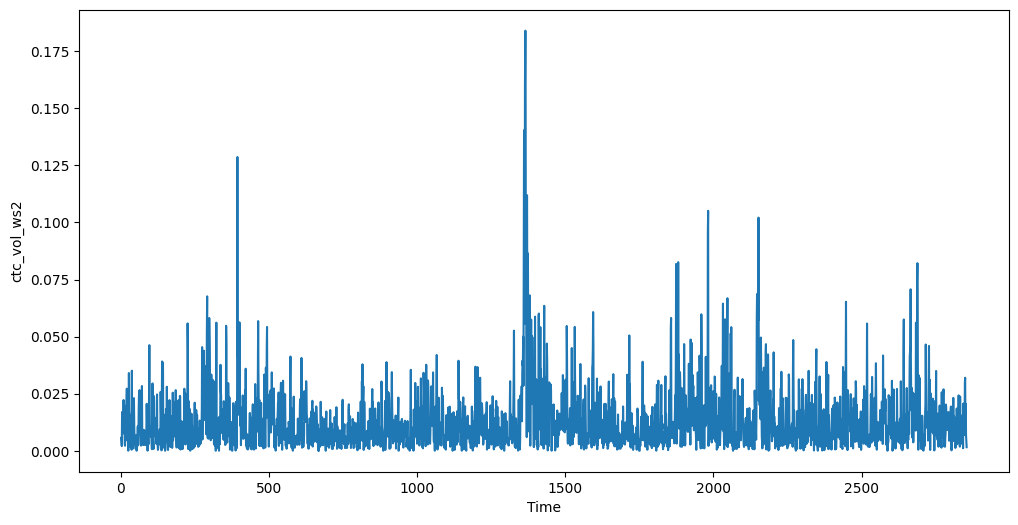

In [72]:
# Optional Plotting
plt.figure(figsize=(12, 6))
plt.plot(df.index, df[target_col]) # Use df.index instead of df['Time']
plt.xlabel('Time')
plt.ylabel(target_col)
plt.show()

In [73]:
# ==========================================
# Define context_df + future_df
# ==========================================

# Make sure data is perfectly ordered before splitting
df = df.sort_values([id_col, date_col]).reset_index(drop=True)

# Filter dataset from split_start_date onwards
df_split = df[df[date_col] >= pd.Timestamp(split_start_date)]
df_split = df_split.sort_values(date_col).reset_index(drop=True)

# Compute split points
n_total = len(df_split)
n_train = int(np.floor(train_fraction * n_total))

context_df = df_split.iloc[:n_train].copy()
future_df = df_split.iloc[n_train:].copy()

# Show sizes
print("Context length:", len(context_df))
print("Future length :", len(future_df))
print("----- Context DF ----- ")
print(context_df.head())
print(context_df.tail())
print("----- Future DF ----- ")
print(future_df.head())
print(future_df.tail())

Context length: 1234
Future length : 309
----- Context DF ----- 
   timestamp        id  ctc_vol_ws2
0 2020-01-01  series_1     0.011684
1 2020-01-02  series_1     0.018857
2 2020-01-03  series_1     0.030445
3 2020-01-06  series_1     0.009917
4 2020-01-07  series_1     0.016023
      timestamp        id  ctc_vol_ws2
1229 2024-09-17  series_1     0.005476
1230 2024-09-18  series_1     0.004268
1231 2024-09-19  series_1     0.007935
1232 2024-09-20  series_1     0.023217
1233 2024-09-23  series_1     0.019254
----- Future DF ----- 
      timestamp        id  ctc_vol_ws2
1234 2024-09-24  series_1     0.002232
1235 2024-09-25  series_1     0.024686
1236 2024-09-26  series_1     0.038340
1237 2024-09-27  series_1     0.022958
1238 2024-09-30  series_1     0.003196
      timestamp        id  ctc_vol_ws2
1538 2025-11-24  series_1     0.010722
1539 2025-11-25  series_1     0.020573
1540 2025-11-26  series_1     0.006611
1541 2025-11-27  series_1     0.004079
1542 2025-11-28  series_1     0.0

In [64]:
# ===========================
# Load Chronos-2 Model
# ===========================

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map = device,
)

#### Predict the full horizon in one go

In [20]:
# ======================================
# Build  Chronos and inference
# ======================================

"""
Chronos-2 can take two seperate dfs as inputs to perform forecasting. 
The context_df and the future_df. Only the context_df is mandatory.

The context_df includes:
- historical portion of data - including target, features, id, timestamp - that chronos uses to understand past behaviour and patterns.
- must include target
- can include past known covariates and features

The future_df includes:
- only timestamps and optional future-known covaraites for which predictions should be generated
- does NOT inlude the target
- typically represents the forecast horizon --> the part after the split
"""

# prediction length
pred_len = len(future_df)
if pred_len <= 0:
    raise ValueError("future_df is empty, no prediction possible.")

# Build columns sets for Chronos
# Note: in context_cols you have everything needed. in future_cols you just leave out the target_col
context_cols = [id_col, date_col, target_col] + feature_cols
future_cols = [id_col, date_col] + feature_cols

context_df_chronos = context_df[context_cols].reset_index(drop=True)
future_df_chronos = future_df[future_cols].reset_index(drop=True)

print(context_df_chronos.head())
print(future_df_chronos.head())

# Run Chronos inference
pred_df = pipeline.predict_df(
    context_df_chronos,
    #future_df = future_df_chronos,
    prediction_length= 10,
    quantile_levels = [0.1, 0.5, 0.9],
    id_column = id_col,
    timestamp_column = date_col,
    target = target_col
)

pred_df.head()


         id  timestamp  ctc_vol_ws2    return     volume
0  series_1 2020-01-01     0.000540  0.006400  2540641.0
1  series_1 2020-01-02     0.000540  0.006400  2540641.0
2  series_1 2020-01-03     0.002759 -0.016254  2627427.0
3  series_1 2020-01-06     0.008941 -0.002360  2318490.0
4  series_1 2020-01-07     0.016023  0.020505  4237634.0
         id  timestamp    return     volume
0  series_1 2024-09-20 -0.016447  1397232.0
1  series_1 2024-09-23  0.010702   950498.0
2  series_1 2024-09-24  0.013898  1374732.0
3  series_1 2024-09-25 -0.020888  1165142.0
4  series_1 2024-09-26  0.033667  2491452.0


,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,series_1,2024-09-20,ctc_vol_ws2,0.007544,0.002531,0.007544,0.019624
1,series_1,2024-09-23,ctc_vol_ws2,0.007817,0.002439,0.007817,0.020779
2,series_1,2024-09-24,ctc_vol_ws2,0.008040,0.002276,0.008040,0.021074
3,series_1,2024-09-25,ctc_vol_ws2,0.008041,0.002193,0.008041,0.021109
4,series_1,2024-09-26,ctc_vol_ws2,0.008247,0.002314,0.008247,0.021835


In [21]:
# ======================================
# Merge predictions with the true values
# ======================================

results = pred_df.merge(
    future_df[[id_col, date_col, target_col]],
    on=[id_col, date_col],
    how="left"
)

y_true = results[target_col].astype(float)
y_pred_median = results["0.5"].astype(float)

results.head()


,id,timestamp,target_name,predictions,0.1,0.5,0.9,ctc_vol_ws2
0,series_1,2024-09-20,ctc_vol_ws2,0.007544,0.002531,0.007544,0.019624,0.023217
1,series_1,2024-09-23,ctc_vol_ws2,0.007817,0.002439,0.007817,0.020779,0.019254
2,series_1,2024-09-24,ctc_vol_ws2,0.008040,0.002276,0.008040,0.021074,0.002232
3,series_1,2024-09-25,ctc_vol_ws2,0.008041,0.002193,0.008041,0.021109,0.024686
4,series_1,2024-09-26,ctc_vol_ws2,0.008247,0.002314,0.008247,0.021835,0.038340


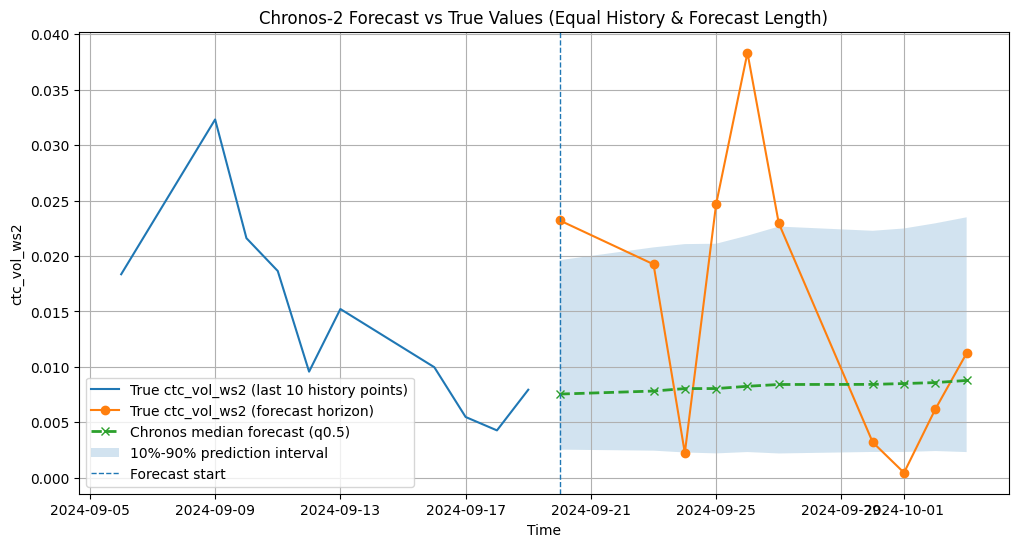

In [22]:
# ===========================
# Plot
# ===========================

# How many steps were predicted
pred_len = len(results)

# Take exactly the last pred_len historical points
hist_part = context_df[[date_col, target_col]].copy()
hist_part = hist_part.sort_values(date_col).tail(pred_len)

# True future (for the forecast horizon)
true_future_part = future_df[[date_col, target_col]].copy()
true_future_part = true_future_part.sort_values(date_col).head(pred_len)

# Forecast (median + optional intervals)
forecast_part = results[[date_col, "0.5"]].copy().sort_values(date_col)

plt.figure(figsize=(12, 6))

# Plot historical true (same length as forecast)
plt.plot(
    hist_part[date_col],
    hist_part[target_col].astype(float),
    label=f"True {target_col} (last {pred_len} history points)",
    linewidth=1.5
)

# Plot true future values
plt.plot(
    true_future_part[date_col],
    true_future_part[target_col].astype(float),
    label=f"True {target_col} (forecast horizon)",
    linewidth=1.5,
    marker="o"
)

# Plot median forecast
plt.plot(
    forecast_part[date_col],
    forecast_part["0.5"].astype(float),
    label="Chronos median forecast (q0.5)",
    linestyle="--",
    linewidth=2,
    marker="x"
)

# Optional uncertainty band if available
if "0.1" in results.columns and "0.9" in results.columns:
    plt.fill_between(
        results[date_col],
        results["0.1"].astype(float),
        results["0.9"].astype(float),
        alpha=0.2,
        label="10%-90% prediction interval"
    )

# Vertical line at forecast start
split_ts = true_future_part[date_col].min()
plt.axvline(split_ts, linestyle="--", linewidth=1, label="Forecast start")

plt.title("Chronos-2 Forecast vs True Values (Equal History & Forecast Length)")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.show()


In [23]:
# ===========================
# Metrics
# ===========================

# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred_median))

# MAE
mae = mean_absolute_error(y_true, y_pred_median)

# Adjusted R Squared
r2 = r2_score(y_true, y_pred_median)
n = len(y_true)
p = len(feature_cols)

if n - p - 1 > 0:
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adj_r2 = np.nan  # not defined if too few samples vs features

# Quantile Loss (Pinball loss)
valid_mask = ~y_true.isna()
def pinball_loss(y, yhat, q):
    diff = y - yhat
    return np.mean(np.maximum(q * diff, (q - 1)* diff))

quantile_losses = {}
for q in [0.1, 0.5, 0.9]:
    q_str = str(q)
    yhat_q = results[q_str].astype(float)[valid_mask]
    quantile_losses[q] = pinball_loss(y_true.values, yhat_q.values, q)

# CRPS approximation
qs = np.array(sorted(quantile_losses.keys()))
Ls = np.array([quantile_losses[q] for q in qs])
crps = 2 * np.trapezoid(Ls, qs)

# Print
print("CRPS (approx.):", crps)
print("RMSE:", rmse)
print("MAE:", mae)
print("Adjusted R^2:", adj_r2)
print("Quantile Losses:")
for q, Lq in quantile_losses.items():
    print(f"--> q={q}: {Lq}")


CRPS (approx.): 0.006308651357269262
RMSE: 0.013814151721671308
MAE: 0.011233075618670511
Adjusted R^2: -0.7609824821223816
Quantile Losses:
--> q=0.1: 0.0014756002249590784
--> q=0.5: 0.0056165378093352555
--> q=0.9: 0.0030629525495435646


### More realistic approach - Rolling backtest
You only predict the next day. You repeat that until you have predicted the whole prediction horizon.

In [ ]:
# ==========================================
# Rolling Backtest: 1-Schritt-Vorhersage
# ==========================================

"""
Idea:
- We simulate that we only know the data up to yesterday each day.
- We start with the original context_df.
- For each day in future_df:
    - Context = context_df + all previously observed “future” days (with real targets)
    - We call Chronos with prediction_length=1 and WITHOUT future_df.    
    - We save the 1-step prediction and move on to the next day.
"""

# Ensure that context_df and future_df exist
assert 'context_df' in globals(), "context_df is not defined. Please execute the split cell first."
assert 'future_df' in globals(), "future_df is not defined. Please execute the split cell first."

# Assembly of Train + Test (only for correct time sequence)
df_roll = pd.concat([context_df, future_df], ignore_index=True)
df_roll = df_roll.sort_values(date_col).reset_index(drop=True)

initial_context_len = len(context_df)
horizon_len = len(future_df)

print(f"Initiale Kontext-Länge: {initial_context_len}")
print(f"Rolling-Horizont (Anzahl Tage im future_df): {horizon_len}")

rolling_pred_list = []

for step in range(horizon_len):
    
    # Context: all data up to and including day t-1
    end_idx = initial_context_len + step  # exclusive slicing, i.e., up to end_idx-1.
    context_step = df_roll.iloc[:end_idx].copy()
    
    # For Chronos: same columns as in your normal inference
    context_step_chronos = context_step[[id_col, date_col, target_col] + feature_cols].reset_index(drop=True)

    # 1-step prediction without future_df
    step_pred_df = pipeline.predict_df(
        context_step_chronos,
        prediction_length = 1,
        quantile_levels   = [0.1, 0.5, 0.9],
        id_column         = id_col,
        timestamp_column  = date_col,
        target            = target_col
    )
    
    # Save step
    rolling_pred_list.append(step_pred_df)
    
    # Optional: Show progress
    if (step + 1) % 10 == 0 or step == horizon_len - 1:
        print(f"Rolling Step {step + 1}/{horizon_len} fertig.")

# All 1-step predictions in a row
rolling_pred_df = pd.concat(rolling_pred_list, ignore_index=True)

print("Rolling-Predictions (nur Vorhersagen):")
print(rolling_pred_df.head())
print(rolling_pred_df.tail())

# Now, similar to your normal pipeline, we join the real values from future_df.
results_rolling = rolling_pred_df.merge(
    future_df[[id_col, date_col, target_col]],
    on=[id_col, date_col],
    how="left"
)

# y_true and median prediction for rolling backtesting
y_true_rolling = results_rolling[target_col].astype(float)
y_pred_median_rolling = results_rolling["0.5"].astype(float)

print("Rolling-Ergebnis (mit True-Werten):")
print(results_rolling.head())
print(results_rolling.tail())


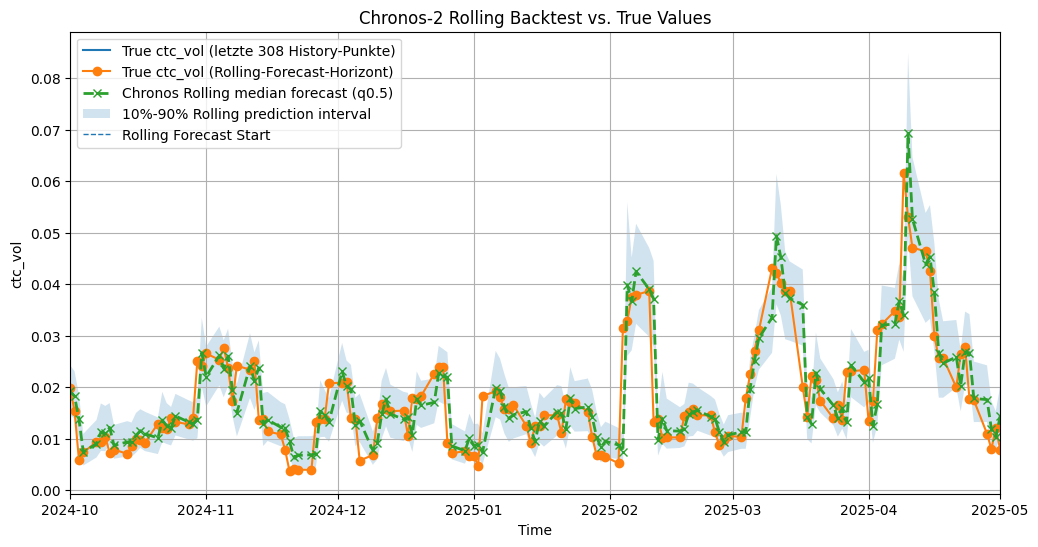

In [ ]:
# ===========================
# Plot: Rolling Backtest
# ===========================

# How many steps were predicted
pred_len_roll = len(results_rolling)

# historical data
hist_part_roll = context_df[[date_col, target_col]].copy()
hist_part_roll = hist_part_roll.sort_values(date_col).tail(pred_len_roll)

# True future 
true_future_part_roll = future_df[[date_col, target_col]].copy()
true_future_part_roll = true_future_part_roll.sort_values(date_col).head(pred_len_roll)

# Rolling Forecast (Median + optional intevals)
forecast_part_roll = results_rolling[[date_col, "0.5"]].copy().sort_values(date_col)

plt.figure(figsize=(12, 6))

# Plot historical true (same length as forecast)
plt.plot(
    hist_part_roll[date_col],
    hist_part_roll[target_col].astype(float),
    label=f"True {target_col} (letzte {pred_len_roll} History-Punkte)",
    linewidth=1.5
)

# Plot true future values
plt.plot(
    true_future_part_roll[date_col],
    true_future_part_roll[target_col].astype(float),
    label=f"True {target_col} (Rolling-Forecast-Horizont)",
    linewidth=1.5,
    marker="o"
)

# Plot Rolling median forecast
plt.plot(
    forecast_part_roll[date_col],
    forecast_part_roll["0.5"].astype(float),
    label="Chronos Rolling median forecast (q0.5)",
    linestyle="--",
    linewidth=2,
    marker="x"
)

# Optional uncertainty band if available
if "0.1" in results_rolling.columns and "0.9" in results_rolling.columns:
    plt.fill_between(
        results_rolling[date_col],
        results_rolling["0.1"].astype(float),
        results_rolling["0.9"].astype(float),
        alpha=0.2,
        label="10%-90% Rolling prediction interval"
    )

# vertical line at rolling forecast start
split_ts_roll = true_future_part_roll[date_col].min()
plt.axvline(split_ts_roll, linestyle="--", linewidth=1, label="Rolling Forecast Start")

plt.title("Chronos-2 Rolling Backtest vs. True Values")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.xlim(pd.Timestamp("2024-10-01"), pd.Timestamp("2025-05-01"))
plt.show()


In [58]:
# ===========================
# Metrics – Rolling Backtest
# ===========================

# RMSE
rmse_rolling = np.sqrt(mean_squared_error(y_true_rolling, y_pred_median_rolling))

# MAE
mae_rolling = mean_absolute_error(y_true_rolling, y_pred_median_rolling)

# Adjusted R Squared
r2_rolling = r2_score(y_true_rolling, y_pred_median_rolling)
n_roll = len(y_true_rolling)
p_roll = len(feature_cols)

if n_roll - p_roll - 1 > 0:
    adj_r2_rolling = 1 - (1 - r2_rolling) * (n_roll - 1) / (n_roll - p_roll - 1)
else:
    adj_r2_rolling = np.nan 

# Quantile Loss (Pinball loss)
valid_mask_roll = ~y_true_rolling.isna()

def pinball_loss(y, yhat, q):
    diff = y - yhat
    return np.mean(np.maximum(q * diff, (q - 1) * diff))

quantile_losses_rolling = {}
for q in [0.1, 0.5, 0.9]:
    q_str = str(q)
    yhat_q_roll = results_rolling[q_str].astype(float)[valid_mask_roll]
    quantile_losses_rolling[q] = pinball_loss(y_true_rolling.values, yhat_q_roll.values, q)

# CRPS-Approximation
qs_roll = np.array(sorted(quantile_losses_rolling.keys()))
Ls_roll = np.array([quantile_losses_rolling[q] for q in qs_roll])
crps_rolling = 2 * np.trapezoid(Ls_roll, qs_roll)

# Print
print("== Rolling Backtest Metrics ==")
print("CRPS (approx., rolling):", crps_rolling)
print("RMSE (rolling):", rmse_rolling)
print("MAE (rolling):", mae_rolling)
print("Adjusted R^2 (rolling):", adj_r2_rolling)
print("Quantile Losses (rolling):")
for q, Lq in quantile_losses_rolling.items():
    print(f"--> q={q}: {Lq}")


== Rolling Backtest Metrics ==
CRPS (approx., rolling): 0.001925167265076241
RMSE (rolling): 0.004736887868661249
MAE (rolling): 0.003118947152023463
Adjusted R^2 (rolling): 0.6867568048909942
Quantile Losses (rolling):
--> q=0.1: 0.0007070684133287585
--> q=0.5: 0.0015594735760117316
--> q=0.9: 0.0009869025973383808


### Rolling Backtest V2

In [74]:
import warnings

def run_rolling_backtest(
    context_df: pd.DataFrame,
    future_df: pd.DataFrame,
    pipeline,
    target_col: str = target_col,
    feature_cols: list = feature_cols,
    date_col: str = date_col,
    id_col: str | None = id_col,
    quantile_levels: list[float] = [0.1, 0.5, 0.9],
) -> pd.DataFrame:
    """
    1-Day-Ahead Rolling Forecast:
    - starte mit context_df
    - gehe Tag für Tag durch future_df
    - sage immer nur 1 Tag voraus
    - danach tatsächlichen Wert an Kontext anhängen
    - kein Data Leakage
    - gibt alle 10 Vorhersagen eine Statusmeldung aus
    """
    warnings.filterwarnings("ignore", message=".*pin_memory.*")

    resolved_id_col = id_col if id_col is not None else "id"

    # Sortieren
    sort_cols = [resolved_id_col, date_col]
    context_df = context_df.sort_values(sort_cols).reset_index(drop=True)
    future_df = future_df.sort_values(sort_cols).reset_index(drop=True)

    records = []
    total_steps = len(future_df)

    for step_idx in range(total_steps):

        # Historie bis gestern
        history_df = pd.concat(
            [context_df, future_df.iloc[:step_idx]],
            axis=0,
            ignore_index=True,
        )

        # Chronos Input
        chronos_cols = [resolved_id_col, date_col, target_col] + feature_cols
        chronos_input = history_df[chronos_cols].copy()

        # 1-Tages-Vorhersage
        pred_df = pipeline.predict_df(
            chronos_input,
            prediction_length=1,
            quantile_levels=quantile_levels,
            id_column=resolved_id_col,
            timestamp_column=date_col,
            target=target_col,
        )

        pred_row = pred_df.iloc[-1]
        ts_pred = pred_row[date_col]

        # echte Werte
        true_row = future_df.iloc[step_idx]
        true_ts = true_row[date_col]
        true_val = true_row[target_col]

        # <-- Sanity-Check:
        if ts_pred != true_ts:
            print(
                f"[WARN] Timestamp mismatch im Schritt {step_idx}: "
                f"ts_pred={ts_pred}, true_ts={true_ts}"
            )

        # Ergebnis speichern
        rec = {
            date_col: true_ts,
            "y_true": true_val,
            "y_pred": pred_row["0.5"],
        }

        for q in quantile_levels:
            rec[f"q_{q}"] = pred_row[str(q)]

        records.append(rec)

        # Statusmeldung: alle 10 Schritte
        if (step_idx + 1) % 10 == 0:
            print(f"Forecasts done: {step_idx + 1}/{total_steps}")

    return pd.DataFrame(records).sort_values(date_col).reset_index(drop=True)


In [75]:
backtest_results = run_rolling_backtest(
    context_df=context_df,
    future_df=future_df,
    pipeline=pipeline,
)

Forecasts done: 10/309
Forecasts done: 20/309
Forecasts done: 30/309
Forecasts done: 40/309
Forecasts done: 50/309
Forecasts done: 60/309
Forecasts done: 70/309
Forecasts done: 80/309
Forecasts done: 90/309
Forecasts done: 100/309
Forecasts done: 110/309
Forecasts done: 120/309
Forecasts done: 130/309
Forecasts done: 140/309
Forecasts done: 150/309
Forecasts done: 160/309
Forecasts done: 170/309
Forecasts done: 180/309
Forecasts done: 190/309
Forecasts done: 200/309
Forecasts done: 210/309
Forecasts done: 220/309
Forecasts done: 230/309
Forecasts done: 240/309
Forecasts done: 250/309
Forecasts done: 260/309
Forecasts done: 270/309
Forecasts done: 280/309
Forecasts done: 290/309
Forecasts done: 300/309


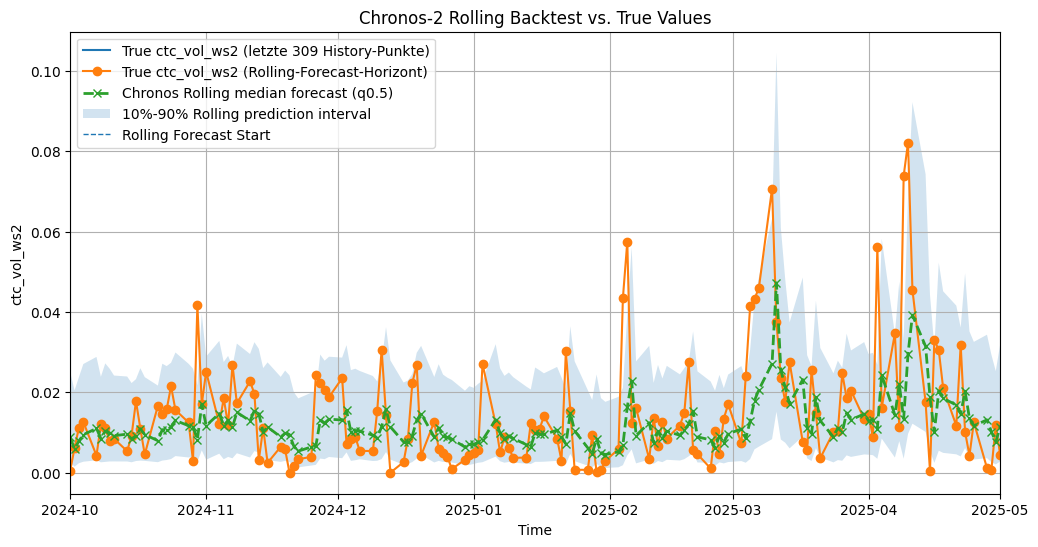

In [76]:
# ===========================
# Plot: Rolling Backtest
# ===========================

# Wie viele Schritte wurden vorhergesagt
pred_len_roll = len(backtest_results)

# Historische Daten (gleiche Länge wie Vorhersage)
hist_part_roll = context_df[[date_col, target_col]].copy()
hist_part_roll = hist_part_roll.sort_values(date_col).tail(pred_len_roll)

# True future (gleiche Länge wie Vorhersage)
true_future_part_roll = future_df[[date_col, target_col]].copy()
true_future_part_roll = true_future_part_roll.sort_values(date_col).head(pred_len_roll)

# Rolling Forecast (Median)
forecast_part_roll = backtest_results[[date_col, "y_pred"]].copy().sort_values(date_col)

plt.figure(figsize=(12, 6))

# Plot historische True-Werte (gleiche Länge wie Forecast)
plt.plot(
    hist_part_roll[date_col],
    hist_part_roll[target_col].astype(float),
    label=f"True {target_col} (letzte {pred_len_roll} History-Punkte)",
    linewidth=1.5
)

# Plot echte zukünftige Werte
plt.plot(
    true_future_part_roll[date_col],
    true_future_part_roll[target_col].astype(float),
    label=f"True {target_col} (Rolling-Forecast-Horizont)",
    linewidth=1.5,
    marker="o"
)

# Plot Rolling median forecast
plt.plot(
    forecast_part_roll[date_col],
    forecast_part_roll["y_pred"].astype(float),
    label="Chronos Rolling median forecast (q0.5)",
    linestyle="--",
    linewidth=2,
    marker="x"
)

# Optional: Unsicherheitsband, falls Quantile vorhanden sind
if "q_0.1" in backtest_results.columns and "q_0.9" in backtest_results.columns:
    tmp_sorted = backtest_results.sort_values(date_col)
    plt.fill_between(
        tmp_sorted[date_col],
        tmp_sorted["q_0.1"].astype(float),
        tmp_sorted["q_0.9"].astype(float),
        alpha=0.2,
        label="10%-90% Rolling prediction interval"
    )

# Vertikale Linie am Rolling-Forecast-Start
split_ts_roll = true_future_part_roll[date_col].min()
plt.axvline(split_ts_roll, linestyle="--", linewidth=1, label="Rolling Forecast Start")

plt.title("Chronos-2 Rolling Backtest vs. True Values")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)

# Optional: x-Achse limitieren – ggf. anpassen oder auskommentieren
plt.xlim(pd.Timestamp("2024-10-01"), pd.Timestamp("2025-05-01"))

plt.show()


In [77]:
# ===========================
# Metrics – Rolling Backtest
# ===========================

# True & Median Vorhersage
y_true_rolling = backtest_results["y_true"].astype(float)
y_pred_median_rolling = backtest_results["y_pred"].astype(float)

# RMSE
rmse_rolling = np.sqrt(mean_squared_error(y_true_rolling, y_pred_median_rolling))

# MAE
mae_rolling = mean_absolute_error(y_true_rolling, y_pred_median_rolling)

# Adjusted R Squared
r2_rolling = r2_score(y_true_rolling, y_pred_median_rolling)
n_roll = len(y_true_rolling)
p_roll = len(feature_cols)

if n_roll - p_roll - 1 > 0:
    adj_r2_rolling = 1 - (1 - r2_rolling) * (n_roll - 1) / (n_roll - p_roll - 1)
else:
    adj_r2_rolling = np.nan 

# Quantile Loss (Pinball loss)
valid_mask_roll = ~y_true_rolling.isna()

def pinball_loss(y, yhat, q):
    diff = y - yhat
    return np.mean(np.maximum(q * diff, (q - 1) * diff))

quantile_losses_rolling = {}
for q in [0.1, 0.5, 0.9]:
    q_col = f"q_{q}"
    if q_col not in backtest_results.columns:
        continue
    yhat_q_roll = backtest_results[q_col].astype(float)[valid_mask_roll]
    quantile_losses_rolling[q] = pinball_loss(
        y_true_rolling.values[valid_mask_roll],
        yhat_q_roll.values,
        q,
    )

# CRPS-Approximation (nur wenn Quantile vorhanden)
if len(quantile_losses_rolling) > 0:
    qs_roll = np.array(sorted(quantile_losses_rolling.keys()))
    Ls_roll = np.array([quantile_losses_rolling[q] for q in qs_roll])
    crps_rolling = 2 * np.trapezoid(Ls_roll, qs_roll)
else:
    crps_rolling = np.nan

# Print
print("== Rolling Backtest Metrics ==")
print("CRPS (approx., rolling):", crps_rolling)
print("RMSE (rolling):", rmse_rolling)
print("MAE (rolling):", mae_rolling)
print("Adjusted R^2 (rolling):", adj_r2_rolling)
print("Quantile Losses (rolling):")
for q, Lq in quantile_losses_rolling.items():
    print(f"--> q={q}: {Lq}")


== Rolling Backtest Metrics ==
CRPS (approx., rolling): 0.004410754886422372
RMSE (rolling): 0.011090975617619098
MAE (rolling): 0.0074850858618996105
Adjusted R^2 (rolling): 0.12875332338000844
Quantile Losses (rolling):
--> q=0.1: 0.0012106688683968514
--> q=0.5: 0.0037425429309498053
--> q=0.9: 0.0023311324857594705


#### Test 1 UBS
target_col = "ctc_vol_ws1"
feature_cols = ["VIX", "Real Middle Band","close", "CHFUSD" ,"SP500"]

== Rolling Backtest Metrics ==

CRPS (approx., rolling): 0.004454856877455203

RMSE (rolling): 0.011175463465087247

MAE (rolling): 0.007579570517942181

Adjusted R^2 (rolling): 0.12015022937556974

Quantile Losses (rolling):

--> q=0.1: 0.001228738912202963

--> q=0.5: 0.0037897852589710906

--> q=0.9: 0.0023288327634928625


#### Test 2 UBS

target_col = "ctc_vol_ws1"
feature_cols = ["VIX", "Real Middle Band","close", "CHFUSD" ,"SP500"]

== Rolling Backtest Metrics ==

CRPS (approx., rolling): 0.004435113194229341

RMSE (rolling): 0.010918203646028243

MAE (rolling): 0.0075496590329840844

Adjusted R^2 (rolling): 0.14628826252160954

Quantile Losses (rolling):

--> q=0.1: 0.0012363076297921673

--> q=0.5: 0.0037748295164920422

--> q=0.9: 0.0023018163227970993

#### Test 3 UBS

target_col = "ctc_vol_ws1"
feature_cols = ["open", "high", "low", "close", "volume", "VIX", "INFLATION", "CHFUSD" ,"SP500"]

== Rolling Backtest Metrics ==

CRPS (approx., rolling): 0.0043489266035236515

RMSE (rolling): 0.010692171064839091

MAE (rolling): 0.007476640162704225

Adjusted R^2 (rolling): 0.17028040389935573

Quantile Losses (rolling):

--> q=0.1: 0.0012319628443900298

--> q=0.5: 0.0037383200813521124

--> q=0.9: 0.002163713501714873

#### Test 4 UBS
feature_cols = ["return", "volume"]

== Rolling Backtest Metrics ==
CRPS (approx., rolling): 0.004236755140941735

RMSE (rolling): 0.010474668966452064

MAE (rolling): 0.007313916297917387

Adjusted R^2 (rolling): 0.2091240394656425

Quantile Losses (rolling):

--> q=0.1: 0.0012079612900895798

--> q=0.5: 0.0036569581489586936

--> q=0.9: 0.0020700102643473705


#### Test 5 UBS
feature_cols = ["return", "volume", "VIX", "INFLATION"]

== Rolling Backtest Metrics ==

CRPS (approx., rolling): 0.004289575576297378

RMSE (rolling): 0.010527996796441026

MAE (rolling): 0.007382259252262579

Adjusted R^2 (rolling): 0.1957944007092829

Quantile Losses (rolling):

--> q=0.1: 0.001233773443515385

--> q=0.5: 0.0036911296261312896

--> q=0.9: 0.002107906244965481

#### Test 6 UBS
feature_cols = ["return", "volume", "VIX"]

== Rolling Backtest Metrics ==

CRPS (approx., rolling): 0.00419752591432677

RMSE (rolling): 0.010400622451700212

MAE (rolling): 0.007262147399725642

Adjusted R^2 (rolling): 0.21097374562826998

Quantile Losses (rolling):

--> q=0.1: 0.0012227283038454028

--> q=0.5: 0.003631073699862821

--> q=0.9: 0.00200893908224588

#### Test 7 UBS

["ctc_vol_lag_1", "ctc_vol_lag_2", "ctc_vol_lag_3","abs_log_return_lag_1", "abs_log_return","abs_log_return_lag_2", "abs_log_return_lag_3"]

== Rolling Backtest Metrics ==

CRPS (approx., rolling): 0.004121263863590617

RMSE (rolling): 0.010262291326591537

MAE (rolling): 0.0069728983318407154

Adjusted R^2 (rolling): 0.23673643257468702

Quantile Losses (rolling):

--> q=0.1: 0.0011934920172457476

--> q=0.5: 0.0034864491659203577

--> q=0.9: 0.00213676930989008
